# III) Binary liver segmentation: U_Net Extended
## Mansour Arefi
### CM2026 Advanced Machine Learning for Data-driven-Health

Summary of what changed from the baseline:
- `DoubleConv` now includes BatchNorm ---> fixes the val-Dice instability
- Combined BCE + Dice loss ---> optimises the evaluation metric
- `ReduceLROnPlateau` scheduler → LR adapts when val loss plateaus
- Richer augmentation → ElasticTransform, Rotate, BrightnessContrast
- Early stopping (patience 15) + periodic checkpoints every 20 epochs

## 1. Imports/device/Path

In [1]:
!pip install -q albumentations opencv-python-headless

In [2]:
import os, gc, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import albumentations as A

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## These are the parameters that can be changed:

In [ ]:
#None: Whole dataset of 100 patients
NUM_PATIENTS = 40

SLICE_POLICY = "all"     
#This is used only when "SLICE_POLICY = balanced"
NEGATIVE_KEEP_RATIO = 0.3      
IMG_SIZE = 256

#Training
BATCH_SIZE= 8
NUM_EPOCHS= 80
LR_INIT = 1e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0
ES_PATIENCE = 15                
CKPT_EVERY = 20                

LOSS_ALPHA = 0.5              


LR_PATIENCE = 8
LR_FACTOR = 0.5

In [ ]:
PATIENT_INDEX_CSV = "/kaggle/input/datasets/mansourarefi/volyms-v1/abdomen_cache_volumes/meta/patient_index.csv"
SPLIT_JSON = "/kaggle/input/datasets/mansourarefi/volyms-v1/abdomen_cache_volumes/meta/split.json"
STATS_JSON = "/kaggle/input/datasets/mansourarefi/volyms-v1/abdomen_cache_volumes/meta/stats.json"
VOLUME_DIR = "/kaggle/input/datasets/mansourarefi/volyms-v1/abdomen_cache_volumes/volumes"
CKPT_DIR = Path(f"/kaggle/working/checkpoints_n{NUM_PATIENTS}")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

LATEST_CKPT = CKPT_DIR / "checkpoint_latest.pt"
BEST_CKPT = CKPT_DIR / "best_model.pt"
HISTORY_JSON = CKPT_DIR / "history.json"
 
torch.manual_seed(42); np.random.seed(42)
print(f"Running with NUM_PATIENTS={NUM_PATIENTS}")

Running with NUM_PATIENTS=40


## 2. Load metadata 

In [ ]:
df_all = pd.read_csv(PATIENT_INDEX_CSV)

with open(SPLIT_JSON)  as f: 
    split = json.load(f)
    
with open(STATS_JSON)  as f: 
    stats = json.load(f)

dataset_mean = stats["mean"]
dataset_std = stats["std"]
CLIP_RANGE = tuple(stats["clip_range"])


In [ ]:
if NUM_PATIENTS is not None:
    n_train = max(1, int(NUM_PATIENTS * 0.60))
    n_val = max(1, int(NUM_PATIENTS * 0.20))
    n_test = NUM_PATIENTS - n_train - n_val
    caps = {"train": n_train, "val": n_val, "test": n_test}
else:
    caps = {"train": None, "val": None, "test": None}

# Slice each split down to its cap (None = keep all)
train_ids, val_ids, test_ids = [
    split[k][:caps[k]] for k in ("train", "val", "test")
]

print(f"Patients — train:{len(train_ids)}  val:{len(val_ids)}  test:{len(test_ids)}")

available = set(df_all["case_id"])
train_ids = [i for i in train_ids if i in available]
val_ids = [i for i in val_ids   if i in available]
test_ids = [i for i in test_ids  if i in available]

print(f"After filtering — train:{len(train_ids)}  val:{len(val_ids)}  test:{len(test_ids)}")




Patients — train:24  val:8  test:8
After filtering — train:24  val:8  test:8


In [ ]:
def build_slice_index(case_ids, volume_dir, slice_policy="all", neg_ratio=1.0):
    rows = []
    
    for cid in tqdm(case_ids, desc="Building slice index"):
        row = df_all[df_all["case_id"] == cid]
        
        if len(row) == 0: continue
        npz_name = row.iloc[0]["npz_name"]
        
        data = np.load(Path(volume_dir) / npz_name)
        liver_vol = data["liver_vol"]
        
        depth = liver_vol.shape[2]
        pos_mask = liver_vol.sum(axis=(0,1)) > 0
        
        pos_idx  = np.where( pos_mask)[0]
        neg_idx  = np.where(~pos_mask)[0]

        if slice_policy == "all":
            sel = np.arange(depth)
        elif slice_policy == "positive_only":
            sel = pos_idx
        elif slice_policy == "balanced":
            rng = np.random.default_rng(SEED)
            n_neg = int(len(neg_idx) * neg_ratio)
            neg_sel = rng.choice(neg_idx, size=min(n_neg, len(neg_idx)), replace=False)
            sel = np.sort(np.concatenate([pos_idx, neg_sel]))
        else:
            raise ValueError(slice_policy)

        for z in sel:
            rows.append({"case_id": cid, "npz_name": npz_name,
                         "slice_idx": int(z), "has_liver": int(pos_mask[z])})
    return pd.DataFrame(rows)


df_train_sl = build_slice_index(train_ids, VOLUME_DIR, SLICE_POLICY, NEGATIVE_KEEP_RATIO)
df_val_sl = build_slice_index(val_ids,   VOLUME_DIR, SLICE_POLICY)
df_test_sl = build_slice_index(test_ids,  VOLUME_DIR, SLICE_POLICY)

print(f"Slices  — train:{len(df_train_sl)}  val:{len(df_val_sl)}  test:{len(df_test_sl)}")
print(f"Train liver balance: {df_train_sl['has_liver'].value_counts().to_dict()}")

Building slice index:   0%|          | 0/24 [00:00<?, ?it/s]

Building slice index:   0%|          | 0/8 [00:00<?, ?it/s]

Building slice index:   0%|          | 0/8 [00:00<?, ?it/s]

Slices  — train:5382  val:4132  test:2517
Train liver balance: {0: 3283, 1: 2099}


## 3. Augmentation

In [ ]:
height, width = IMG_SIZE, IMG_SIZE

# Richer augmentation vs baseline 
train_transform = A.Compose([
    A.Resize(height, width),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
    A.ElasticTransform(alpha=30, sigma=5, p=0.3),
])

val_transform = A.Compose([
    A.Resize(height, width),
])

## 4. Dataset

In [ ]:
class SegmentationDatasetExtended(Dataset):
    def __init__(self, df_slices, volume_dir, transform=None, clip_range=(-100,400), mean=None, std=None):
        self.df          = df_slices.reset_index(drop=True)
        self.volume_dir  = Path(volume_dir)
        self.transform   = transform
        self.clip_range  = clip_range
        self.mean        = mean
        self.std         = std
        self.volume_cache     = {}

    def __len__(self): 
        return len(self.df)

    def _load(self, npz_name):
        if npz_name not in self.volume_cache:
            data = np.load(self.volume_dir / npz_name)
            self.volume_cache[npz_name] = (
                data["ct_vol"].astype(np.float32),
                data["liver_vol"].astype(np.uint8)
            )
        return self.volume_cache[npz_name]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        npz_name = row["npz_name"]
        z = int(row["slice_idx"])

        ct_vol, liver_vol = self._load(npz_name)

        image = ct_vol[:, :, z].copy()
        mask = liver_vol[:, :, z].copy().astype(np.int64)

        image = np.clip(image, *self.clip_range)

        if self.mean is not None and self.std is not None:
            image = (image - self.mean) / (self.std + 1e-8)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask


train_ds = SegmentationDatasetExtended(df_train_sl, VOLUME_DIR, train_transform, CLIP_RANGE, dataset_mean, dataset_std)
val_ds = SegmentationDatasetExtended(df_val_sl,   VOLUME_DIR, val_transform, CLIP_RANGE, dataset_mean, dataset_std)
test_ds = SegmentationDatasetExtended(df_test_sl,  VOLUME_DIR, val_transform, CLIP_RANGE, dataset_mean, dataset_std)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print(f"Batches — train:{len(train_loader)}  val:{len(val_loader)}  test:{len(test_loader)}")

Batches — train:673  val:517  test:315


## 5. Model — U-Net with BatchNorm

`DoubleConv` now inserts `BatchNorm2d` after each convolution.  
This normalises activations between layers, making the loss surface smoother, allows larger effective LR and eliminating the wild val-Dice swings seen in the baseline. 
acts as implicit regularisation

In [ ]:
class DoubleConv(nn.Module):
    """Conv → BN → ReLU → Conv → BN → ReLU.
    BatchNorm added vs baseline (had Conv → ReLU → Conv → ReLU).
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels,  out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        
    def forward(self, x): 
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=2, features=(64,128,256,512)):
        super().__init__()
        
        self.downs = nn.ModuleList()
        self.pools = nn.ModuleList()
        
        self.up_transpose = nn.ModuleList()
        self.ups = nn.ModuleList()

        in_ch = in_channels
        for f in features:
            self.downs.append(DoubleConv(in_ch, f))
            self.pools.append(nn.MaxPool2d(2, 2))
            in_ch = f

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        in_ch = features[-1]*2
        
        for f in reversed(features):
            self.up_transpose.append(
                nn.ConvTranspose2d(in_ch, f, 2, stride=2)
            )
            self.ups.append(DoubleConv(f*2, f))
            in_ch = f

        self.final_conv = nn.Conv2d(features[0], num_classes, 1)

    def forward(self, x):
        skips = []
        for down, pool in zip(self.downs, self.pools):
            x = down(x); skips.append(x); x = pool(x)
        x = self.bottleneck(x)
        for i, (upt, up) in enumerate(zip(self.up_transpose, self.ups)):
            x = upt(x)
            skip = skips[-(i+1)]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
            x = torch.cat((skip, x), dim=1)
            x = up(x)
        return self.final_conv(x)


def init_weights_kaiming(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
        if m.bias is not None: nn.init.constant_(m.bias, 0.0)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

model = UNet(in_channels=1, num_classes=2).to(device)
model.apply(init_weights_kaiming)
print(f"Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Parameters: 31,036,546


## 6. Loss, optimiser, scheduler

- Added soft Dice component: `0.5×CE + 0.5×Dice` — Dice directly optimises the metric and handles class imbalance better than class-weighted CE alone
- Added `ReduceLROnPlateau` — LR halves after 8 epochs without val improvement
- Added AMP scaler for mixed-precision training

In [ ]:
class SoftDiceLoss(nn.Module):
    """Differentiable Dice on class-1 probabilities from a 2-class softmax.
    CE loss optimises log-likelihood per pixel; Dice optimises
    the overlap metric directly and is insensitive to class imbalance.
    """
    def __init__(self, smooth=1.0): super().__init__(); self.s = smooth
    def forward(self, logits, targets):
        # logits: [B,2,H,W]  targets: [B,H,W] long
        prob = torch.softmax(logits, dim=1)[:, 1]   # P(liver)
        t = (targets == 1).float()
        inter = (prob * t).sum(dim=(1,2))
        union = prob.sum(dim=(1,2)) + t.sum(dim=(1,2))
        return (1 - (2*inter + self.s) / (union + self.s)).mean()


class CombinedLoss(nn.Module):
    """alpha * CE  +  (1-alpha) * SoftDice"""
    def __init__(self, alpha, class_weights):
        super().__init__()
        self.alpha = alpha
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.dice = SoftDiceLoss()
        
    def forward(self, logits, targets):
        return self.alpha * self.ce(logits, targets) +  (1 - self.alpha) * self.dice(logits, targets)


# Class weights (same estimation approach as baseline)
def estimate_class_weights(dataset, max_samples=500):
    fg = bg = 0
    for i in tqdm(range(min(max_samples, len(dataset))), desc="Estimating class weights"):
        _, m = dataset[i]
        fg += (m==1).sum().item()
        bg += (m==0).sum().item()
    total = fg + bg
    return torch.tensor([total/(2*bg), total/(2*fg)], dtype=torch.float32)

class_weights = estimate_class_weights(train_ds).to(device)
print("Class weights:", class_weights)

criterion = CombinedLoss(alpha=LOSS_ALPHA, class_weights=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LR_INIT, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max",
                factor=LR_FACTOR, patience=LR_PATIENCE)
scaler = torch.amp.GradScaler('cuda') #AMP — mixed-precision training

Estimating class weights:   0%|          | 0/500 [00:00<?, ?it/s]

Class weights: tensor([ 0.5207, 12.5981], device='cuda:0')


## 7. Metrics

In [ ]:
def dice_score(logits, targets, eps=1e-8):
    """Dice on the argmax prediction (same as baseline for comparability)."""
    preds = torch.argmax(logits, dim=1).float()
    targets = targets.float()
    inter = (preds * targets).sum(dim=(1,2))
    union = preds.sum(dim=(1,2)) + targets.sum(dim=(1,2))
    return ((2*inter + eps) / (union + eps)).mean().item()
ij
def iou_score(logits, targets, eps=1e-8):
    preds = torch.argmax(logits, dim=1).float()
    targets = targets.float()
    inter = (preds * targets).sum(dim=(1,2))
    union = preds.sum(dim=(1,2)) + targets.sum(dim=(1,2)) - inter
    return ((inter + eps) / (union + eps)).mean().item()

## 8. Checkpoint helpers

In [ ]:
def save_checkpoint(state, path):
    torch.save(state, path)
    print(f"  checkpoint saved -> {path}")

def load_checkpoint(path, model, optimizer=None, scheduler=None):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model"])
    if optimizer  and "optimizer"  in ckpt: optimizer.load_state_dict(ckpt["optimizer"])
    if scheduler  and "scheduler"  in ckpt: scheduler.load_state_dict(ckpt["scheduler"])
    print(f"  resumed from epoch {ckpt['epoch']}  (best val dice: {ckpt['best_val_dice']:.4f})")
    return ckpt["epoch"], ckpt["best_val_dice"]

def make_state(epoch, model, optimizer, scheduler, best_val_dice):
    return {"epoch": epoch, "model": model.state_dict(),
            "optimizer": optimizer.state_dict(), "scheduler": scheduler.state_dict(),
            "best_val_dice": best_val_dice}

## 9. Training loop

In [14]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total_loss = total_dice = n = 0
    for images, masks in loader:
        images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            logits = model(images)
            loss   = criterion(logits, masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer); scaler.update()
        total_loss += loss.item()
        total_dice += dice_score(logits.detach(), masks)
        n += 1
    return total_loss/n, total_dice/n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = total_dice = total_iou = n = 0
    for images, masks in loader:
        images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        with torch.amp.autocast('cuda'):
            logits = model(images)
            loss   = criterion(logits, masks)
        total_loss += loss.item()
        total_dice += dice_score(logits, masks)
        total_iou  += iou_score(logits, masks)
        n += 1
    return total_loss/n, total_dice/n, total_iou/n

In [15]:
# Resume if a checkpoint exists
start_epoch   = 0
best_val_dice = 0.0

if LATEST_CKPT.exists():
    start_epoch, best_val_dice = load_checkpoint(LATEST_CKPT, model, optimizer, scheduler)

es_counter = 0
history = {"train_loss":[], "train_dice":[], "val_loss":[], "val_dice":[], "val_iou":[]}

for epoch in range(start_epoch, NUM_EPOCHS):
    train_loss, train_dice = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
    val_loss, val_dice, val_iou = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_dice)   # ReduceLROnPlateau monitors val Dice (mode=max)

    history["train_loss"].append(train_loss); history["train_dice"].append(train_dice)
    history["val_loss"].append(val_loss);     history["val_dice"].append(val_dice)
    history["val_iou"].append(val_iou)

    print(f"Epoch {epoch+1:03d}/{NUM_EPOCHS} | "
          f"train loss={train_loss:.4f} dice={train_dice:.4f} | "
          f"val loss={val_loss:.4f} dice={val_dice:.4f} iou={val_iou:.4f} | "
          f"lr={optimizer.param_groups[0]['lr']:.2e}")

    state = make_state(epoch+1, model, optimizer, scheduler, best_val_dice)
    save_checkpoint(state, LATEST_CKPT)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        state["best_val_dice"] = best_val_dice
        save_checkpoint(state, BEST_CKPT)
        es_counter = 0
    else:
        es_counter += 1
        print(f"  no improvement ({es_counter}/{ES_PATIENCE})")

    if (epoch+1) % CKPT_EVERY == 0:
        save_checkpoint(state, CKPT_DIR / f"epoch_{epoch+1:03d}.pt")

    if es_counter >= ES_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}"); break

with open(HISTORY_JSON, "w") as f: json.dump(history, f, indent=2)
print(f"\nDone. Best val Dice: {best_val_dice:.4f}")

Epoch 001/80 | train loss=0.4944 dice=0.3074 | val loss=0.4269 dice=0.4699 iou=0.4404 | lr=1.00e-04
  checkpoint saved -> /kaggle/working/checkpoints_n40/checkpoint_latest.pt
  checkpoint saved -> /kaggle/working/checkpoints_n40/best_model.pt
Epoch 002/80 | train loss=0.3475 dice=0.6268 | val loss=0.1371 dice=0.8957 iou=0.8759 | lr=1.00e-04
  checkpoint saved -> /kaggle/working/checkpoints_n40/checkpoint_latest.pt
  checkpoint saved -> /kaggle/working/checkpoints_n40/best_model.pt
Epoch 003/80 | train loss=0.2693 dice=0.7523 | val loss=0.1278 dice=0.8421 iou=0.8160 | lr=1.00e-04
  checkpoint saved -> /kaggle/working/checkpoints_n40/checkpoint_latest.pt
  no improvement (1/15)
Epoch 004/80 | train loss=0.2307 dice=0.7826 | val loss=0.1040 dice=0.8741 iou=0.8507 | lr=1.00e-04
  checkpoint saved -> /kaggle/working/checkpoints_n40/checkpoint_latest.pt
  no improvement (2/15)
Epoch 005/80 | train loss=0.2082 dice=0.8042 | val loss=0.1096 dice=0.9253 iou=0.9061 | lr=1.00e-04
  checkpoint sav

## 10. Training curves

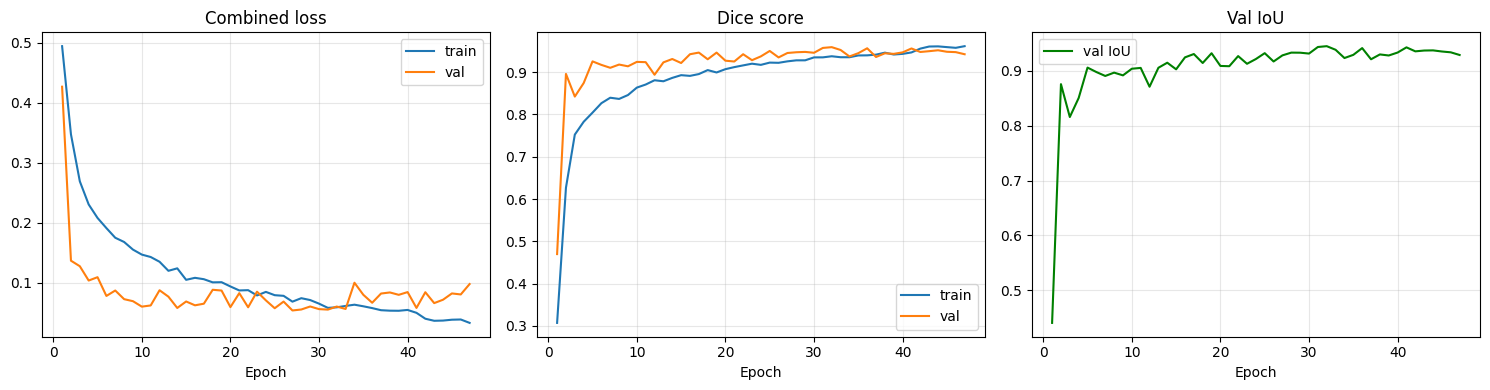

In [16]:
if HISTORY_JSON.exists():
    with open(HISTORY_JSON) as f: history = json.load(f)

ep = range(1, len(history["train_loss"])+1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ep, history["train_loss"], label="train")
axes[0].plot(ep, history["val_loss"],   label="val")
axes[0].set_title("Combined loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history["train_dice"], label="train")
axes[1].plot(ep, history["val_dice"],   label="val")
axes[1].set_title("Dice score"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(ep, history["val_iou"], color="green", label="val IoU")
axes[2].set_title("Val IoU"); axes[2].set_xlabel("Epoch")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CKPT_DIR / "training_curves.png", dpi=100)
plt.show()

## 11. Test-set evaluation

In [17]:
best_model = UNet(in_channels=1, num_classes=2).to(device)
best_model.load_state_dict(torch.load(BEST_CKPT, map_location=device)["model"])
best_model.eval()

test_loss, test_dice, test_iou = evaluate(best_model, test_loader, criterion, device)
print(f"=== TEST RESULTS  (N={NUM_PATIENTS} patients) ===")
print(f"  Loss : {test_loss:.4f}")
print(f"  Dice : {test_dice:.4f}")
print(f"  IoU  : {test_iou:.4f}")

exp_cfg = {
    "num_patients": NUM_PATIENTS,
    "slice_policy": SLICE_POLICY,
    "image_size": IMG_SIZE,
    "clip_range": list(CLIP_RANGE),
    "optimizer": "AdamW",
    "lr_init": LR_INIT, "weight_decay": WEIGHT_DECAY,
    "loss": f"CE+Dice (alpha={LOSS_ALPHA})",
    "batch_size": BATCH_SIZE,
    "batchnorm": True,
    "scheduler": "ReduceLROnPlateau",
    "amp": True,
    "best_val_dice": best_val_dice,
    "test_dice": test_dice,
    "test_iou": test_iou,
    "n_train_patients": len(train_ids),
    "n_val_patients":   len(val_ids),
    "n_test_patients":  len(test_ids),
}
with open(CKPT_DIR / "experiment_config.json", "w") as f:
    json.dump(exp_cfg, f, indent=2)
print(json.dumps(exp_cfg, indent=2))

=== TEST RESULTS  (N=40 patients) ===
  Loss : 0.3340
  Dice : 0.8899
  IoU  : 0.8704
{
  "num_patients": 40,
  "slice_policy": "all",
  "image_size": 256,
  "clip_range": [
    -100,
    400
  ],
  "optimizer": "AdamW",
  "lr_init": 0.0001,
  "weight_decay": 0.0001,
  "loss": "CE+Dice (alpha=0.5)",
  "batch_size": 8,
  "batchnorm": true,
  "scheduler": "ReduceLROnPlateau",
  "amp": true,
  "best_val_dice": 0.9589271123458674,
  "test_dice": 0.8898695215301655,
  "test_iou": 0.8704238993372259,
  "n_train_patients": 24,
  "n_val_patients": 8,
  "n_test_patients": 8
}


## 12. Qualitative predictions

Ranking liver slices:   0%|          | 0/2517 [00:00<?, ?it/s]

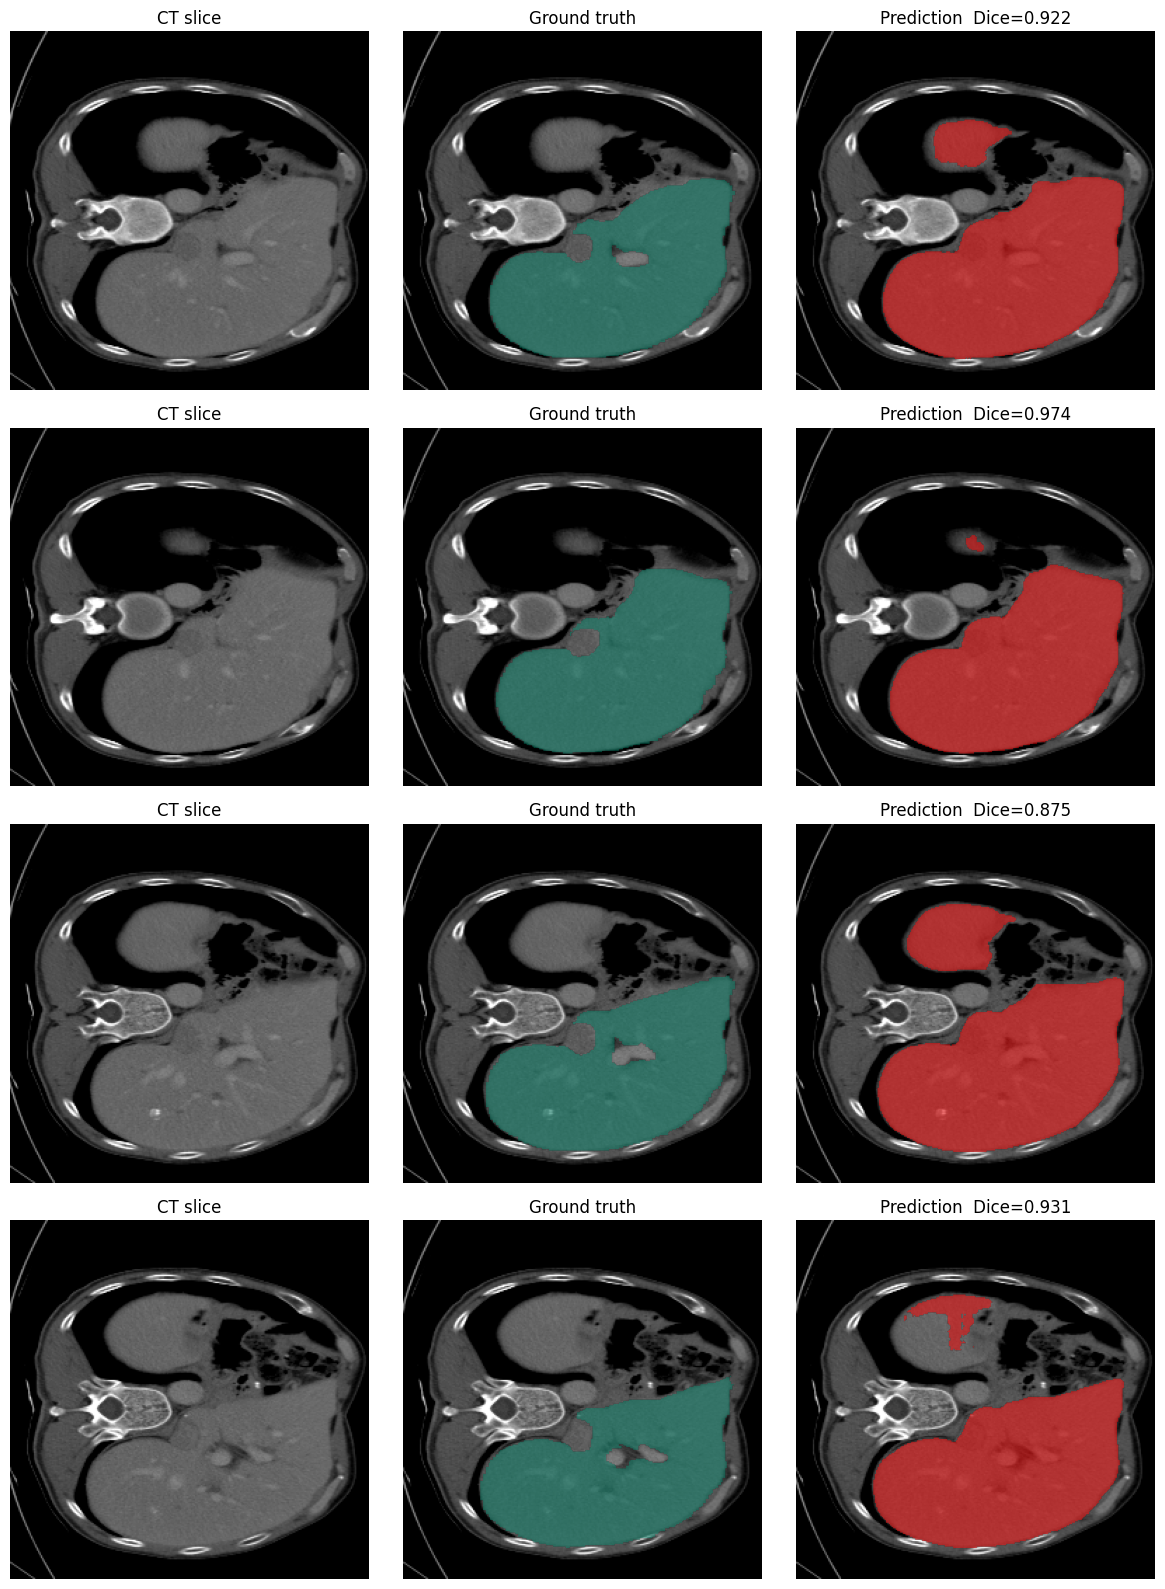

In [18]:
def make_liver_loader(dataset_df, volume_dir, n_samples=8, batch_size=4):
    """Return a loader whose first batch contains the slices with most liver pixels."""
    rows = []
    for _, row in tqdm(dataset_df.iterrows(), total=len(dataset_df), desc="Ranking liver slices"):
        data  = np.load(Path(volume_dir) / row["npz_name"])
        z     = int(row["slice_idx"])
        score = int(data["liver_vol"][:, :, z].sum())
        rows.append({**row, "liver_px": score})

    top = (pd.DataFrame(rows)
             .sort_values("liver_px", ascending=False)
             .head(n_samples)
             .reset_index(drop=True))

    ds = SegmentationDatasetExtended(top, volume_dir, transform=val_transform,
                                  clip_range=CLIP_RANGE, mean=dataset_mean, std=dataset_std)
    return DataLoader(ds, batch_size=batch_size, shuffle=False)


@torch.no_grad()
def visualize_predictions(model, loader, device, n=4):
    model.eval()
    images, masks = next(iter(loader))
    images, masks = images.to(device), masks.to(device)

    with torch.amp.autocast('cuda'):
        logits = model(images)

    preds  = torch.argmax(logits, dim=1).cpu().numpy()
    images = images.cpu().numpy()
    masks  = masks.cpu().numpy()

    n = min(n, len(images))
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = axes[np.newaxis]

    for i in range(n):
        img, mask, pred = images[i, 0], masks[i], preds[i]
        dice_i = (2 * (pred * mask).sum() + 1e-8) / (pred.sum() + mask.sum() + 1e-8)

        axes[i, 0].imshow(img, cmap="gray")
        axes[i, 0].set_title("CT slice"); axes[i, 0].axis("off")

        axes[i, 1].imshow(img, cmap="gray")
        axes[i, 1].imshow(np.ma.masked_where(mask == 0, mask), cmap="summer", alpha=0.5)
        axes[i, 1].set_title("Ground truth"); axes[i, 1].axis("off")

        axes[i, 2].imshow(img, cmap="gray")
        axes[i, 2].imshow(np.ma.masked_where(pred == 0, pred), cmap="autumn", alpha=0.5)
        axes[i, 2].set_title(f"Prediction  Dice={dice_i:.3f}"); axes[i, 2].axis("off")

    plt.tight_layout()
    plt.savefig(CKPT_DIR / "predictions.png", dpi=100)
    plt.show()


liver_loader = make_liver_loader(df_test_sl, VOLUME_DIR, n_samples=8, batch_size=4)
visualize_predictions(best_model, liver_loader, device, n=4)